# Sharing an error model between two experiments

Two experiments measure the same line, and each one carries its own
normalisation defect.  We know how to give a single dataset an error model; the
question now is what to do when we have two, and we believe something about
them *jointly*.

There are two quite different things we might mean by "they share an error
model", and `rxmc` spells them differently:

- **Case B — share the parameter.**  Each dataset has its own normalisation
  measurement, but we believe the two magnitudes are the same number.  We pass
  the same `Parameter` object to a term on each comparison: one column in the
  chain, two block-diagonal blocks in the covariance, and the datasets stay
  statistically independent.
- **Case A — share the mode.**  Both were normalised against the same uncertain
  flux, so a single unknown moves them together.  One term spans both
  comparisons, and the covariance grows off-diagonal blocks that couple the
  datasets.

They are different statistical models, not two spellings of one.  Recipe 5 has
both; here we watch what each does to the same pair of datasets, including what
it costs us to declare the wrong one.

Recipes: 5

In [1]:
import corner
import dynesty
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx
from rxmc import terms as T

plotstyle.use()

## Two experiments, one line

The first experiment reports 5 % noise and came out 10 % low; the second reports
2.5 % noise and came out 10 % high.  Neither reports a normalisation
uncertainty, so between them they disagree by 20 % while claiming a precision of
a few per cent.

In [2]:
rng = np.random.default_rng(16)
truth = {"m": 0.6, "b": 2.0}

x1 = np.linspace(0.01, 1.0, 15)
y1_true = truth["m"] * x1 + truth["b"]
y1 = (y1_true + rng.normal(0.0, 0.05 * y1_true)) * 0.9  # 10 % low
data1 = rx.Dataset(x1, y1, 0.05 * y1, label="experiment A")

x2 = np.linspace(0.01, 0.8, 27)
y2_true = truth["m"] * x2 + truth["b"]
y2 = (y2_true + rng.normal(0.0, 0.025 * y2_true)) * 1.1  # 10 % high
data2 = rx.Dataset(x2, y2, 0.025 * y2, label="experiment B")

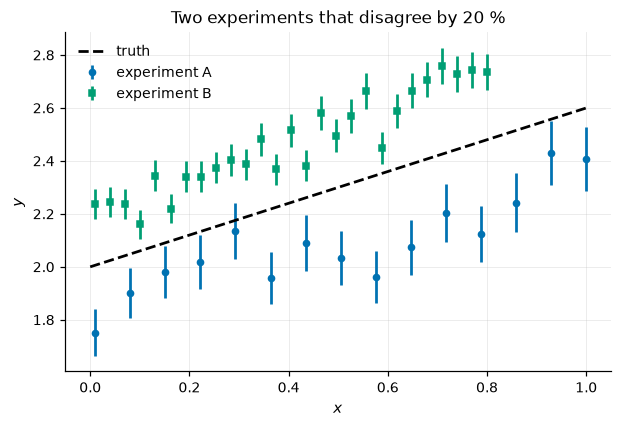

In [3]:
x_fine = np.linspace(0.0, 1.0, 40)
fig, ax = plt.subplots()
ax.errorbar(
    data1.x,
    data1.y,
    data1.y_err,
    fmt="o",
    color=plotstyle.COLOURS[0],
    label=data1.label,
)
ax.errorbar(
    data2.x,
    data2.y,
    data2.y_err,
    fmt="s",
    color=plotstyle.COLOURS[2],
    label=data2.label,
)
ax.plot(x_fine, truth["m"] * x_fine + truth["b"], "--", color="k", label="truth")
ax.set(xlabel="$x$", ylabel="$y$", title="Two experiments that disagree by 20 %")
ax.legend()
plt.show()

## The model and the way we run a fit

We use the same line and the same wide prior as in `error_models`, and three small helpers: `fit`, `band` and `summary`.

One thing is different. There we sampled with emcee, but here we'll use [nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm) through [dynesty](https://dynesty.readthedocs.io/) ([Speagle 2020](https://doi.org/10.1093/mnras/staa278)). When one normalisation mode spans both experiments, the posterior develops a long, thin tail in which the shared scale grows and the line is barely determined. Ensemble walkers that wander into a tail like that tend to stay there, and a few stuck walkers are enough to distort the means and widths we report. Nested sampling works inwards from the whole prior, so it doesn't get stuck that way.

In [4]:
m = rx.Parameter("m", prior=stats.norm(2.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(5.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp1, comp2 = rx.Comparison(data1, line), rx.Comparison(data2, line)

In [5]:
def fit(problem, seed, nlive=250):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=0.5, print_progress=False)
    return sampler.results.samples_equal(rstate=np.random.default_rng(seed))


def band(problem, samples, levels=(5, 95)):
    """The line's own band: how well each error model pins the curve down."""
    return rx.predictive.grid_draws(
        problem,
        line.bind(x_fine),
        x_fine,
        samples[::10],
        model_only=True,
        levels=levels,
    )


def summary(problem, samples):
    return "  ".join(
        f"{n} = {samples[:, i].mean():.3f} +/- {samples[:, i].std():.3f}"
        for i, n in enumerate(problem.names)
    )

## What "shared" means to the compiler

Sharing is by *object identity*, never by name.  Passing one `Parameter` to two
terms gives one column; building two parameters that happen to have the same
name is an error, because the chain would carry two columns with one label.

In [6]:
shared = rx.Parameter("log_eps", prior=stats.norm(np.log(0.05), 1.0))
c_shared = rx.Constraint(
    [comp1, comp2],
    terms=[
        T.proportional_error(shared, on=comp1),
        T.proportional_error(shared, on=comp2),
    ],
    statistical=False,
)
p_shared = rx.Problem([c_shared])
print("one shared object -> one column: ", p_shared.names)

eps1 = rx.Parameter("log_eps_1", prior=stats.norm(np.log(0.05), 1.0))
eps2 = rx.Parameter("log_eps_2", prior=stats.norm(np.log(0.05), 1.0))
c_separate = rx.Constraint(
    [comp1, comp2],
    terms=[T.proportional_error(eps1, on=comp1), T.proportional_error(eps2, on=comp2)],
    statistical=False,
)
print("two objects   -> two columns:   ", rx.Problem([c_separate]).names)

one shared object -> one column:  ['m', 'b', 'log_eps']
two objects   -> two columns:    ['m', 'b', 'log_eps_1', 'log_eps_2']


## Case B: one inferred noise for both

We let a single noise fraction, shared between the datasets, absorb the
disagreement.  It is the only freedom this error model has, so we should expect
it to grow until it covers a 20 % gap that is not noise at all.

In [7]:
s_shared = fit(p_shared, seed=6)
print(summary(p_shared, s_shared))
print(f"inferred noise fraction: {np.exp(s_shared[:, 2]).mean():.3f}")

m = 0.502 +/- 0.138  b = 2.115 +/- 0.068  log_eps = -2.334 +/- 0.114
inferred noise fraction: 0.098


## A normalisation mode per dataset, and then one across both

Two more error models, both of which know what actually happened:

- **a mode per dataset** (still case B in spirit): each experiment gets its own
  rank-one normalisation mode, so each may slide independently;
- **case A**: one mode with `on=[comp1, comp2]`, a single unknown flux that
  moves both together, which fills the off-diagonal blocks.

Our two experiments drifted in *opposite* directions, so we should expect the
per-dataset modes to fit comfortably and case A to struggle: one common factor
cannot pull A up and B down at the same time.

In [8]:
p_stat = rx.Problem([rx.Constraint([comp1, comp2])])
p_per_set = rx.Problem(
    [
        rx.Constraint(
            [comp1, comp2],
            terms=[
                T.normalization(magnitude=0.1, on=comp1),
                T.normalization(magnitude=0.1, on=comp2),
            ],
        )
    ]
)
p_case_a = rx.Problem(
    [
        rx.Constraint(
            [comp1, comp2], terms=[T.normalization(magnitude=0.1, on=[comp1, comp2])]
        )
    ]
)
s_stat = fit(p_stat, seed=7)
s_per_set = fit(p_per_set, seed=8)
s_case_a = fit(p_case_a, seed=9)
for label, p, s in [
    ("statistics only", p_stat, s_stat),
    ("a mode per dataset", p_per_set, s_per_set),
    ("one mode across both (case A)", p_case_a, s_case_a),
]:
    print(f"{label:32s}: {summary(p, s)}")

statistics only                 : m = 0.568 +/- 0.044  b = 2.163 +/- 0.020
a mode per dataset              : m = 0.644 +/- 0.064  b = 2.048 +/- 0.153
one mode across both (case A)   : m = 0.602 +/- 0.081  b = 2.280 +/- 0.255


Here's what each of those error models did.

**Statistics only** is precise and wrong, as usual: $b = 2.163 \pm 0.020$, eight standard deviations from the truth. With no way to say "these two experiments are on different scales", the fit splits the difference between them and believes the result.

**A mode per dataset** matches how the defect actually arose, and it behaves: $m = 0.644 \pm 0.064$ and $b = 2.048 \pm 0.153$, both within a standard deviation of the truth.

**Case A** insists that one unknown moved both experiments together. It can't explain a *relative* disagreement between them, so it compromises. Its line comes out at $m = 0.602 \pm 0.081$ and $b = 2.280 \pm 0.255$. That still covers the truth, but $b$ sits more than a standard deviation high, with an error bar almost twice as wide as the per-dataset model's. The fit doesn't fail loudly; it quietly gives a less accurate and less precise answer, because it's describing a situation that didn't happen.

### The covariance, seen directly

`constraint.matrix(theta)` hands us the assembled covariance, which is the
quickest way to see the difference: a mode per dataset leaves the
cross-experiment blocks empty, while one mode across both fills them in.

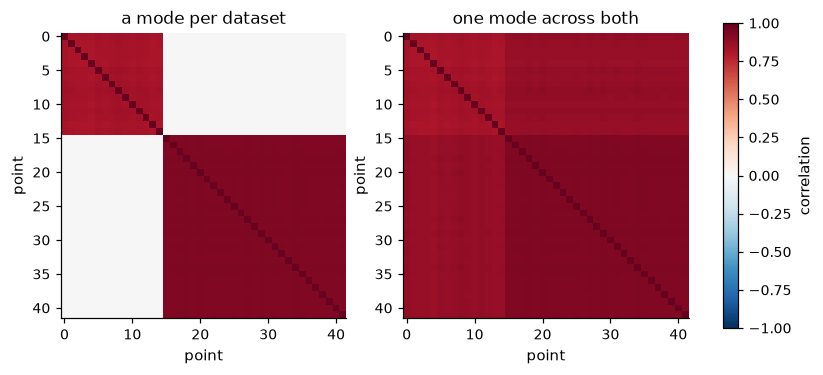

In [9]:
theta = np.array([truth["m"], truth["b"]])
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.6))
for ax, (label, p) in zip(
    axes, [("a mode per dataset", p_per_set), ("one mode across both", p_case_a)]
):
    sigma = p.constraints[0].matrix(theta)
    scale = np.sqrt(np.outer(np.diag(sigma), np.diag(sigma)))
    im = ax.imshow(sigma / scale, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set(title=label, xlabel="point", ylabel="point")
    ax.grid(False)
fig.colorbar(im, ax=axes, label="correlation", fraction=0.03)
plt.show()

In [10]:
# one colour and one line style per error model, so the corner plot below
# stays readable even where the contours overlap
runs = {
    "statistics only": (p_stat, s_stat, plotstyle.COLOURS[0], "-"),
    "shared inferred noise": (p_shared, s_shared, plotstyle.COLOURS[1], "--"),
    "a mode per dataset": (p_per_set, s_per_set, plotstyle.COLOURS[2], "-."),
    "one mode across both": (p_case_a, s_case_a, plotstyle.COLOURS[3], ":"),
}
bands = {label: band(p, s) for label, (p, s, _, _) in runs.items()}

### The fitted line under each error model

Four bands on one set of axes overlap too much to tell apart, so we give each error model its own panel, on the same axes, with the truth and both datasets drawn in every one.

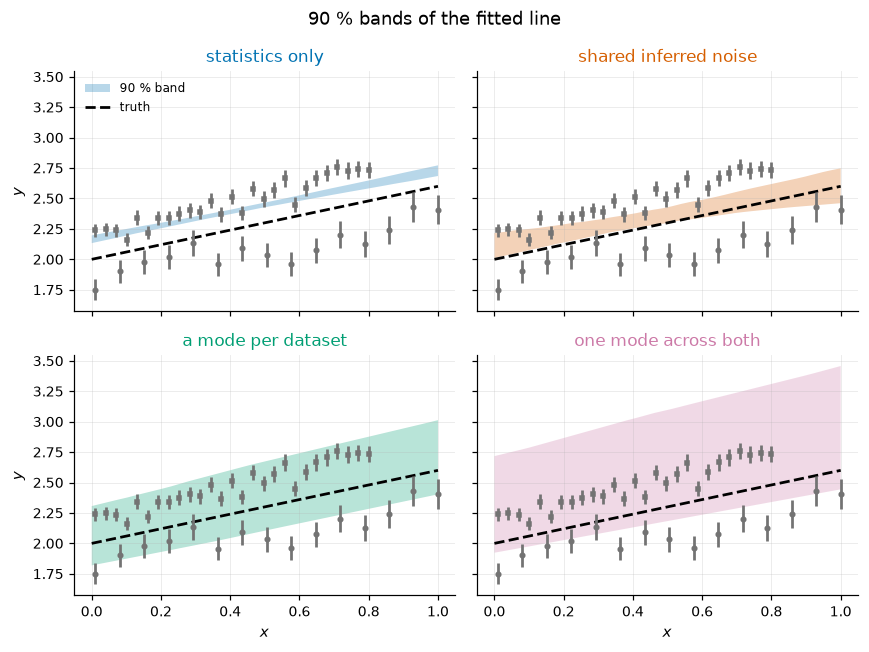

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.0), sharex=True, sharey=True)
for ax, (label, (lo, hi)) in zip(axes.flat, bands.items()):
    colour = runs[label][2]
    plotstyle.band(ax, x_fine, lo, hi, color=colour, label="90 % band")
    ax.plot(x_fine, truth["m"] * x_fine + truth["b"], "--", color="k", label="truth")
    ax.errorbar(data1.x, data1.y, data1.y_err, fmt="o", color="0.45", ms=3)
    ax.errorbar(data2.x, data2.y, data2.y_err, fmt="s", color="0.45", ms=3)
    ax.set_title(label, color=colour)
for ax in axes[1]:
    ax.set_xlabel("$x$")
for ax in axes[:, 0]:
    ax.set_ylabel("$y$")
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("90 % bands of the fitted line")
fig.tight_layout()
plt.show()

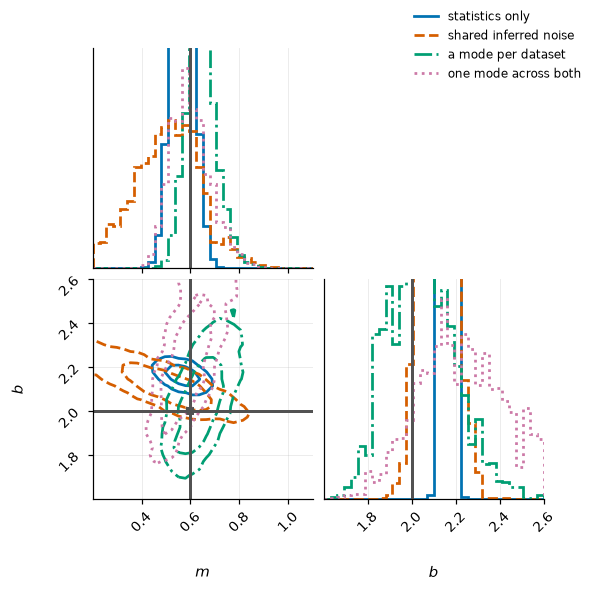

In [12]:
fig = None
for label, (p, s, colour, style) in runs.items():
    fig = corner.corner(
        s[:, p.columns(line.params)],
        fig=fig,
        labels=["$m$", "$b$"],
        truths=[truth["m"], truth["b"]],
        range=[(0.2, 1.1), (1.6, 2.6)],
        **plotstyle.corner_kwargs(
            color=colour,
            fill_contours=False,
            plot_density=False,
            show_titles=False,
            levels=(0.68, 0.95),
            contour_kwargs={"linestyles": style, "linewidths": 1.8},
            hist_kwargs={"linestyle": style, "linewidth": 1.8},
        ),
    )
fig.legend(
    handles=[
        plt.Line2D([], [], color=c, ls=ls, lw=1.8, label=lab)
        for lab, (_, _, c, ls) in runs.items()
    ],
    loc="upper right",
    fontsize=8,
)
plt.show()

## Takeaways

- Sharing a `Parameter` object couples the *parameters*; a term spanning
  comparisons couples the *data*.  Both are declarations, never configuration,
  and the compiler tells us which we wrote: one column, or off-diagonal blocks.
- A shared diagonal noise can only inflate.  Faced with two experiments that
  disagree by 20 %, it grows until it covers the gap, which fits neither the
  data nor the story.
- A normalisation mode per dataset lets each experiment slide on its own, and
  is the model that matches how the defect arose here.
- One mode across both says a single unknown moved them together.  That is a
  stronger statement, and here it is the wrong one: our experiments drifted
  apart, not together, so the fit could only compromise, less accurate and
  less precise than the model that matches what happened.  It
  is the right model when the experiments really do share a calibration —
  recipe 37 is the version for several quantities of one experiment whose
  normalisations are correlated.